# Gaussian NB

The data was preprocessed and a GuassianNB model was fit:
- Numerical columns scaled with StandardScaler
- Categorical columns one hot encoded
- GridSearchCV used to tune the hyperparameters.

The **key results** were:
- **34% Precision for Class 1:**
  - Of all the customers the model predicted would subscribe, only 34% actually did.
- **85% Recall for Class 1:**
  - Of all the customers that subscribed, the model correctly identified 85% of them.
- **93% ROC AUC:**
  - The model has a 93% chance of ranking a customer who did subscribe as more likely to subscribe than a customer who didn't.

This model is good at identifying customers that subscribed (high recall), but many of the customers that the model predicted would subscribe actually didn't (low precision). The precision for class 1 needs to be much higher for the model to be useful.

In [9]:
# change directory to the repository
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\Data\Apziva\uyBvjh22fVpcb3UX")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\Data\\Apziva\\uyBvjh22fVpcb3UX'

In [10]:
# import all the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [11]:
# set random state for the notebook
random_state = 42
np.random.seed(random_state)

Fitting 5 folds for each of 13 candidates, totalling 65 fits
Best Parameters:
{'classifier__var_smoothing': np.float64(1e-12)}
              precision    recall  f1-score   support

           0       0.99      0.39      0.56      7421
           1       0.11      0.97      0.20       579

    accuracy                           0.43      8000
   macro avg       0.55      0.68      0.38      8000
weighted avg       0.93      0.43      0.54      8000



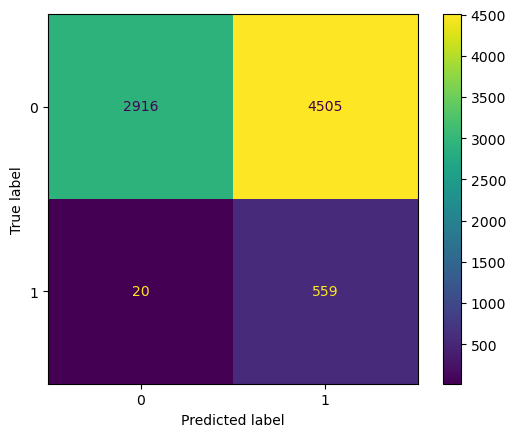

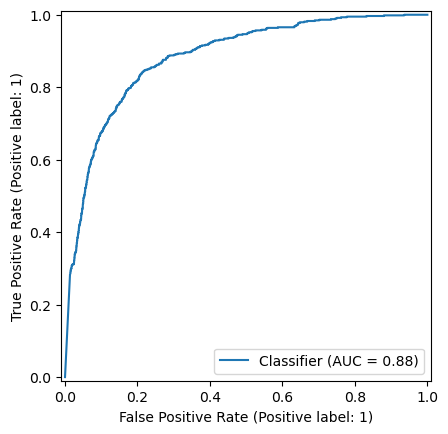

In [18]:
# import the data
data = pd.read_csv("data/processed/processed_data.csv")

# split data into x and y
x = data.select_dtypes(include='object')
y = data['target']

# split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state, stratify=y)

# create a list of features
cat_features = x.select_dtypes(include='object').columns

# preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), cat_features)
    ])

# create a pipeline that performs preprocessing and then creates log reg model
gauss_pipe = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', GaussianNB())
    ])

# hyperparameter options to try when tuning
param_grid = {
    'classifier__var_smoothing': np.logspace(-12, 0, 13)
}

# try different hyperparameter options using cross validation (includes above pipelines)
grid = GridSearchCV(
    gauss_pipe, 
    param_grid, 
    cv=5,
    scoring='recall',
    n_jobs=1, 
    verbose=1
)

# fit pipelines and tuning grid on training data
grid.fit(x_train, y_train)

# display the best parameters
print('Best Parameters:')
print(grid.best_params_)

# use the best model to make predictions from the test set
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

# show classification report containing detailed metrics
print(classification_report(y_test, y_pred))

# show confusion matrix of predicted data vs actual
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# display ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

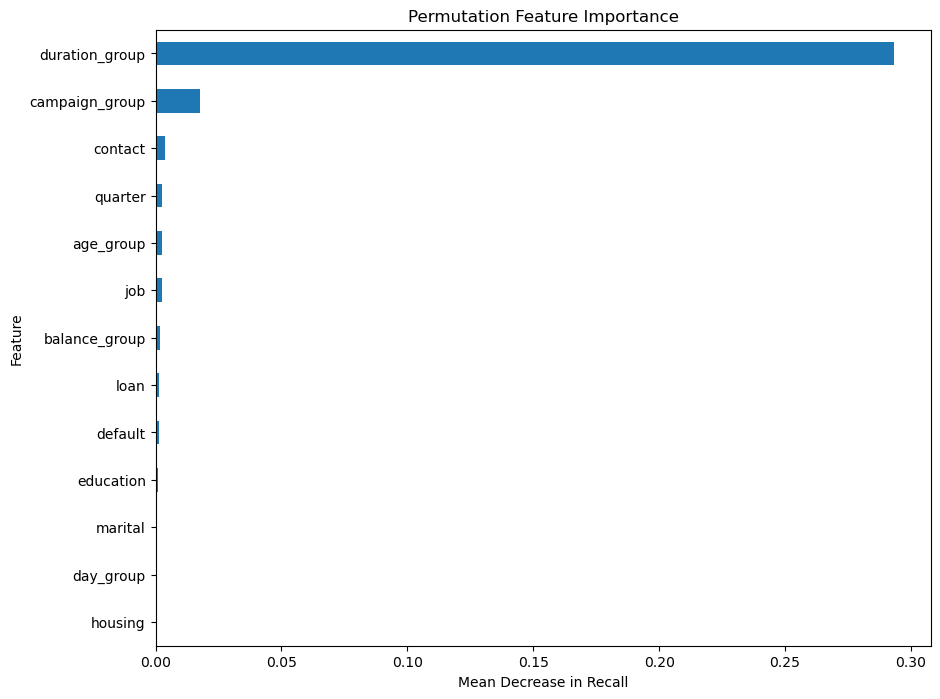

In [19]:
result = permutation_importance(
    best_model,
    x_test,
    y_test,
    scoring='recall',
    n_repeats=10,
    random_state=random_state,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    'feature': x_test.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

feature_importance.sort_values('importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(10, 8),
    legend=False
)

plt.xlabel('Mean Decrease in Recall')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance')
plt.show()